# Import Statements

In [1]:
%pip install tensorflow
import time
import random
import os
import shutil

import PIL
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers, callbacks, layers

Note: you may need to restart the kernel to use updated packages.


# Constants

In [2]:
TRAIN_SPLIT_FRACTION = 0.8
IMAGE_SIZE = (100, 100)

In [3]:
# Path to read-only input directory of kaggle.com
INPUT_DIR_PATH = "./"
# Path to images
IMAGE_DIR_PATH = os.path.join(INPUT_DIR_PATH, "train/")

# Path to read-write working directory of kaggle.com
# WORKING_DIR_PATH = "../working/myImages"
WORKING_DIR_PATH = "./"
IMAGE_TRAIN_DIR_PATH = os.path.join(WORKING_DIR_PATH, "data/train")
IMAGE_TEST_DIR_PATH = os.path.join(WORKING_DIR_PATH, "data/train")

# Model
MODEL_DIR_PATH = os.path.join(WORKING_DIR_PATH, "models/")
MODEL_NAME = "Our_Distracted_Driver"
KERAS_MODEL_PATH = os.path.join(MODEL_DIR_PATH, f"{MODEL_NAME}.keras")
TF_LITE_MODEL_PATH = os.path.join(MODEL_DIR_PATH, f"{MODEL_NAME}.tflite")

# Train-Test Split

In [4]:
# Create dictionary with class name as key and filenames belonging to that class as value
classFilenameDict = {}
for classDir in os.scandir(IMAGE_DIR_PATH):
    className = classDir.name
    if className not in classFilenameDict:
        classFilenameDict[className] = []
        
    for file in os.scandir(classDir):
        classFilenameDict[className].append(file.name)
    

In [5]:
# Create directories to store data in an organized way
if not os.path.exists(IMAGE_TRAIN_DIR_PATH):
    os.makedirs(IMAGE_TRAIN_DIR_PATH)
if not os.path.exists(IMAGE_TEST_DIR_PATH):
    os.makedirs(IMAGE_TEST_DIR_PATH)

In [6]:
for className, imageNames in classFilenameDict.items():
    # Create class directory if not already present
    if not os.path.exists(os.path.join(IMAGE_TRAIN_DIR_PATH, className)):
        os.makedirs(os.path.join(IMAGE_TRAIN_DIR_PATH, className))
    if not os.path.exists(os.path.join(IMAGE_TEST_DIR_PATH, className)):
        os.makedirs(os.path.join(IMAGE_TEST_DIR_PATH, className))
        
    # Train-Test Split
    random.shuffle(imageNames)
    trainSize = int(TRAIN_SPLIT_FRACTION * len(imageNames))
    imageTrainNames = imageNames[: trainSize]
    imageTestNames = imageNames[trainSize:]
    
    # Copy images to the folders
    for imageName in imageTrainNames:
        src = os.path.join(IMAGE_DIR_PATH, className, imageName)
        dest = os.path.join(IMAGE_TRAIN_DIR_PATH, className, imageName)
        shutil.copyfile(src, dest)
        
    for imageName in imageTestNames:
        src = os.path.join(IMAGE_DIR_PATH, className, imageName)
        dest = os.path.join(IMAGE_TEST_DIR_PATH, className, imageName)
        shutil.copyfile(src, dest)

# Load Data

In [15]:
# Convert values from int to float between 0 and 1 by dividing by 255
trainDataGenObj = ImageDataGenerator(rescale=1/255)
trainGen = trainDataGenObj.flow_from_directory(IMAGE_TRAIN_DIR_PATH, target_size=IMAGE_SIZE, class_mode="categorical", batch_size=128)

testDataGenObj = ImageDataGenerator(rescale=1/255)
testGen = testDataGenObj.flow_from_directory(IMAGE_TEST_DIR_PATH, target_size=IMAGE_SIZE, class_mode="categorical", batch_size=128)

Found 25 images belonging to 4 classes.
Found 25 images belonging to 4 classes.


# Create Model

In [16]:
model = tf.keras.models.Sequential([
    # Input layer
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    
    # Hidden layers
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(512, activation="relu"),
    
    # Output layer
    layers.Dense(4, activation="softmax")
])

2025-01-23 13:50:08.263858: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [17]:
model.compile(optimizer=optimizers.Adam(), loss="categorical_crossentropy", metrics=["acc"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,302,948 (12.60 MB)

 Trainable params: 3,302,948 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [18]:
callback = [callbacks.EarlyStopping(monitor="val_acc", patience=4, min_delta=0.01)]

In [19]:
startTime = time.time()
history = model.fit(trainGen, epochs=10, verbose=1, validation_data=testGen, callbacks=callback)
endTime = time.time()
print(f"Time taken: {endTime - startTime:.2f}s")

Epoch 1/10


/home/abhishek/Projects/Python/Char_Recognition/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.2400 - loss: 1.3918 - val_acc: 0.2800 - val_loss: 1.3179
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - acc: 0.2800 - loss: 1.3179 - val_acc: 0.6000 - val_loss: 1.2246
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - acc: 0.6000 - loss: 1.2246 - val_acc: 0.6400 - val_loss: 1.0912
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - acc: 0.6400 - loss: 1.0912 - val_acc: 0.8800 - val_loss: 0.9043
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - acc: 0.8800 - loss: 0.9043 - val_acc: 0.8000 - val_loss: 0.7385
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - acc: 0.8000 - loss: 0.7385 - val_acc: 0.9200 - val_loss: 0.5606
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - acc: 0.9200 - loss: 0.5606 - val_acc: 0.9200 - val_loss: 0.4782
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - acc: 0.9200 - loss: 0.4782 - val_acc: 0.9200 - val_loss: 0.3735
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - acc: 0.9200 - loss: 0.3735 - val_a

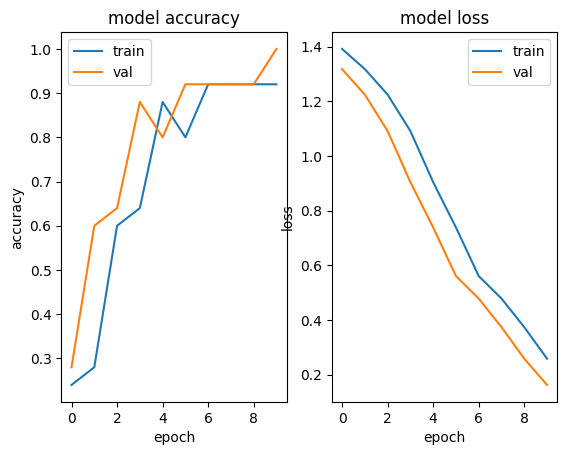

In [20]:
plt.subplot(1, 2, 1)
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.plot(history.history["acc"])
plt.plot(history.history["val_acc"])
plt.legend(['train', 'val'])

plt.subplot(1, 2, 2)

plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(['train', 'val'])

plt.show()

# Make Inference

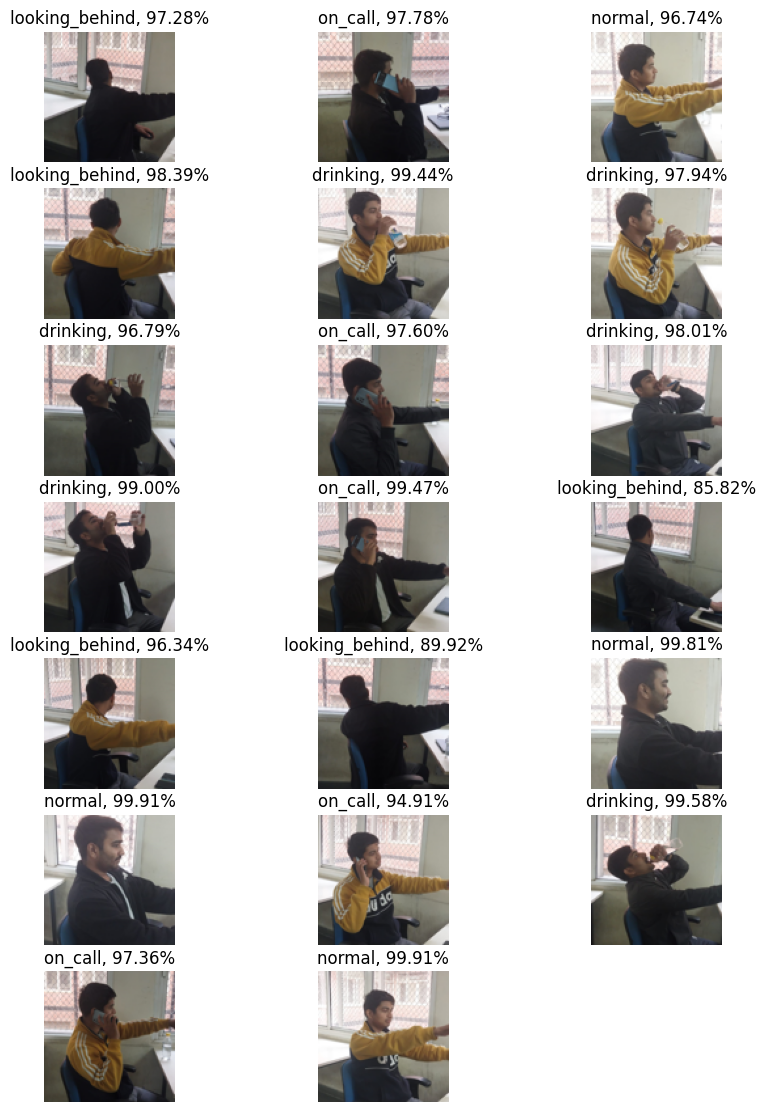

In [18]:
SAMPLE_IMAGE_DIR = os.path.join(INPUT_DIR_PATH, "data/testSamples")
CLASS_LABELS = ['drinking', 'looking_behind', 'normal', 'on_call']

sampleSize = 20
sampleFiles = list(os.scandir(SAMPLE_IMAGE_DIR))
random.Random(0).shuffle(sampleFiles)
# random.shuffle(sampleFiles)
sampleFiles = sampleFiles[: sampleSize]

plt.figure(figsize=(10, 20))
gridDim = (10, 3)
for i, file in enumerate(sampleFiles):
    if i == sampleSize:
        break

    curImg = np.array(PIL.Image.open(file.path).convert("RGB").resize(IMAGE_SIZE)).astype("float32") / 255
    modelInputImg = np.expand_dims(curImg, axis=0)
    modelPrediction = model.predict(modelInputImg, verbose=0)[0]

    confidence = modelPrediction.max()
    predClassIdx = np.argmax(modelPrediction)
    predClassLbl =  CLASS_LABELS[predClassIdx]

    plt.subplot(*gridDim, i + 1)
    plt.imshow(curImg)
    plt.title(f"{predClassLbl}, {confidence * 100 :0.2f}%")

    plt.axis("off")

# Save Model

In [21]:
if not os.path.exists(MODEL_DIR_PATH):
    os.makedirs(MODEL_DIR_PATH)
model.save(KERAS_MODEL_PATH)

# Load Model

In [4]:
model = tf.keras.models.load_model(KERAS_MODEL_PATH)

2025-01-23 13:52:35.270916: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Converting to TF Lite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tfLiteModel = converter.convert()
if not os.path.exists(MODEL_DIR_PATH):
    os.makedirs(MODEL_DIR_PATH)
with open(TF_LITE_MODEL_PATH, "wb") as f:
    f.write(tfLiteModel)

# Inferences using TF Lite model

In [4]:
class TfLiteClassificationModel:
    def __init__(self, model_path):
        self.interpreter = tf.lite.Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()
        self._inputDetails = self.interpreter.get_input_details()
        self._outputDetails = self.interpreter.get_output_details()

    def predict(self, image):
        """
        args:
          image: a (1, imageHeight, imageWidth, 3) np.array

        Returns array of each class probability
        """

        self.interpreter.set_tensor(self._inputDetails[0]["index"], image)
        self.interpreter.invoke()
        output = self.interpreter.get_tensor(self._outputDetails[0]["index"])
        
        return output

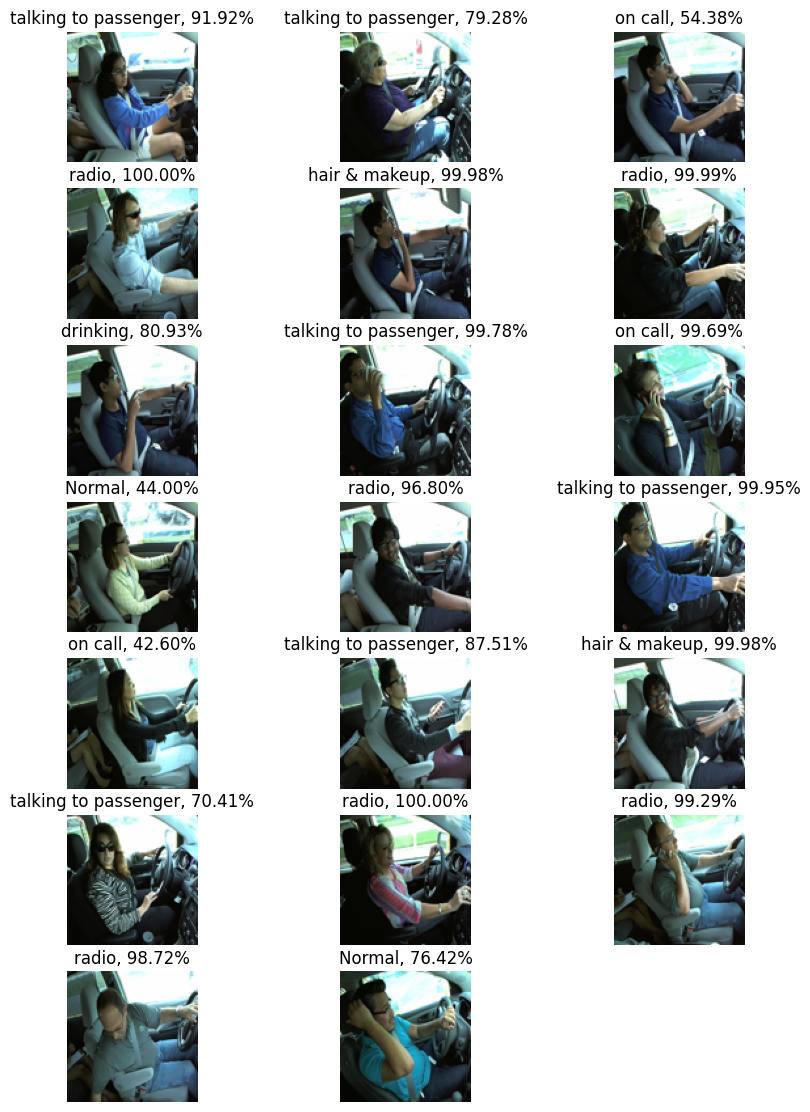

In [ ]:
SAMPLE_IMAGE_DIR = "data/Test_Samples"
CLASS_LABELS = ['Normal', 'texting', 'on call', 'texting', 'on call', 'radio', 'drinking', 'reaching behind', \
                'hair & makeup', 'talking to passenger']

tfLiteModel = TfLiteClassificationModel(TF_LITE_MODEL_PATH)

sampleSize = 20
sampleFiles = list(os.scandir(SAMPLE_IMAGE_DIR))
random.Random(0).shuffle(sampleFiles)
# random.shuffle(sampleFiles)
sampleFiles = sampleFiles[: sampleSize]

plt.figure(figsize=(10, 20))
gridDim = (10, 3)


for i, file in enumerate(sampleFiles):
    if i == sampleSize:
        break

    curImg = np.array(PIL.Image.open(file.path).convert("RGB").resize(IMAGE_SIZE)).astype("float32") / 255

    modelInputImg = np.expand_dims(curImg, axis=0)
    modelPrediction = tfLiteModel.predict(modelInputImg)[0]

    confidence = modelPrediction.max()
    predClassIdx = np.argmax(modelPrediction)
    predClassLbl =  CLASS_LABELS[predClassIdx]

    plt.subplot(*gridDim, i + 1)
    plt.imshow(curImg)
    plt.title(f"{predClassLbl}, {confidence * 100 :0.2f}%")

    plt.axis("off")

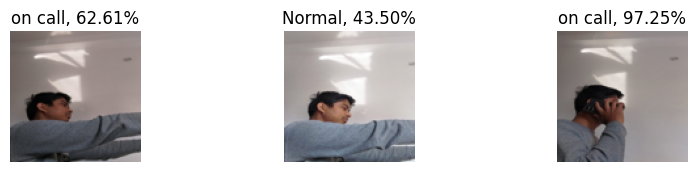

In [7]:
SAMPLE_IMAGE_DIR = "data/Test_Samples"
CLASS_LABELS = ['Normal', 'texting', 'on call', 'texting', 'on call', 'radio', 'drinking', 'reaching behind', \
                'hair & makeup', 'Normal']

tfLiteModel = TfLiteClassificationModel(TF_LITE_MODEL_PATH)

sampleSize = 20
sampleFiles = list(os.scandir(SAMPLE_IMAGE_DIR))
random.Random(0).shuffle(sampleFiles)
# random.shuffle(sampleFiles)
sampleFiles = sampleFiles[: sampleSize]

plt.figure(figsize=(10, 20))
gridDim = (10, 3)


for i, file in enumerate(sampleFiles):
    if i == sampleSize:
        break

    curImg = np.array(PIL.Image.open(file.path).convert("RGB").resize(IMAGE_SIZE)).astype("float32") / 255

    modelInputImg = np.expand_dims(curImg, axis=0)
    modelPrediction = tfLiteModel.predict(modelInputImg)[0]

    confidence = modelPrediction.max()
    predClassIdx = np.argmax(modelPrediction)
    predClassLbl =  CLASS_LABELS[predClassIdx]

    plt.subplot(*gridDim, i + 1)
    plt.imshow(curImg)
    plt.title(f"{predClassLbl}, {confidence * 100 :0.2f}%")

    plt.axis("off")

In [2]:
import time
import cv2

CLASS_LABELS = ['drinking', 'looking_behind', 'normal', 'on_call']

# Open the default camera
cam = cv2.VideoCapture(0)

# Get the default frame width and height
frame_width = int(cam.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cam.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_width = int(100)
frame_height = int(100)

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output.mp4', fourcc, 20.0, (frame_width, frame_height))

while True:
    ret, frame = cam.read()

    # Write the frame to the output file
    out.write(frame)

    # Display the captured frame
    cv2.imshow('Camera', frame)

    frameArray = np.array(frame.resize(*IMAGE_SIZE))
    modelInputImg = np.expand_dims(frameArray, axis=0)
    modelPrediction = model.predict(modelInputImg)[0]
    confidence = modelPrediction.max()
    predClassIdx = np.argmax(modelPrediction)
    predClassLbl =  CLASS_LABELS[predClassIdx]
    print(predClassLbl)

    # Press 'q' to exit the loop
    if cv2.waitKey(1) == ord('q'):
        break
    time.sleep(0.2)

# Release the capture and writer objects
cam.release()
out.release()
cv2.destroyAllWindows()

[ WARN:0@11.524] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@11.525] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


error: OpenCV(4.11.0) /io/opencv/modules/highgui/src/window.cpp:973: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'imshow'


NameError: name 'MODEL_NAME' is not defined